In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
# Customer dataset
data = {
    "Age": [22, 25, 35, 40, 50, 48],
    "Income": [25, 28, 45, 50, 65, 62],
    "SpendingScore": [78, 82, 40, 38, 20, 18]
}
df = pd.DataFrame(data)
df.head()

,Age,Income,SpendingScore
0,22,25,78
1,25,28,82
2,35,45,40
3,40,50,38
4,50,65,20


In [3]:
#feature selection
X = df[['Age', 'Income', 'SpendingScore']]

In [4]:
##scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

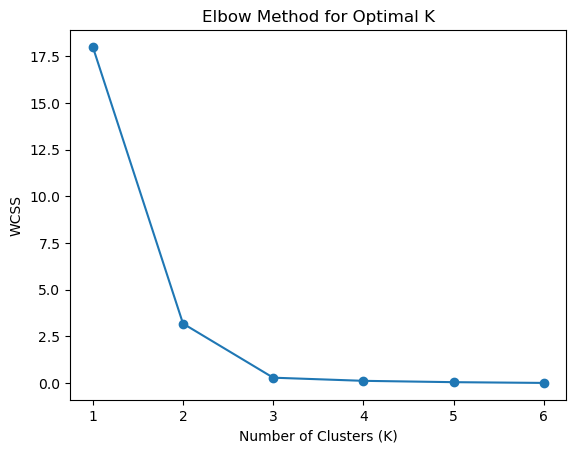

In [5]:
##selecting optimal number of k using elbow method
wcss = []

for k in range(1, 7):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure()
plt.plot(range(1, 7), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method for Optimal K")
plt.show()

In [6]:
wcss

[18.000000000000004,
 3.179178501944709,
 0.28058772868425086,
 0.11216086233638108,
 0.04026945849238508,
 0.0]

In [7]:
#kmeans algorithm
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)
df

,Age,Income,SpendingScore,Cluster
0,22,25,78,2
1,25,28,82,2
2,35,45,40,0
3,40,50,38,0
4,50,65,20,1
5,48,62,18,1


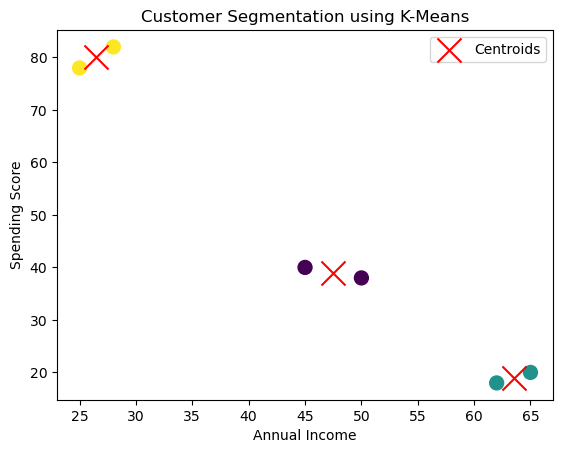

In [8]:
#Visualize the cluster
plt.figure()

plt.scatter(
    df['Income'], df['SpendingScore'], c=df['Cluster'], cmap='viridis', s=100)
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation using K-Means")

#Now plotting centroids
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(
    centroids[:,1], centroids[:,2], s=300, c='red', marker='x', label='Centroids')
plt.legend()
plt.show()

In [9]:
new_customer = [[30, 40, 65]]

# Scale new data
new_customer_scaled = scaler.transform(new_customer)

# Predict cluster
predicted_cluster = kmeans.predict(new_customer_scaled)

print("New customer belongs to Cluster:", predicted_cluster[0])

if predicted_cluster[0] == 0:
    print("High Spender – Premium offers recommended")
elif predicted_cluster[0] == 1:
    print("Medium Spender – Discount coupons recommended")
else:
    print("Low Spender – Budget deals recommended")

New customer belongs to Cluster: 2
Low Spender – Budget deals recommended


C:\ProgramData\Anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
